In [1]:
# --- CELL 1: Import All Required Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier  # <--- CHANGED THIS
from sklearn.metrics import (accuracy_score, classification_report, 
                           confusion_matrix, roc_auc_score, roc_curve,
                           precision_recall_curve, average_precision_score)
from category_encoders import TargetEncoder
import warnings
warnings.filterwarnings('ignore')

# Bayesian Optimization
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical, Real

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# --- CELL 2: Load and Prepare Data ---
# Load your dataset
df = pd.read_csv('heart_original.csv') 

# Remove rows with NULL values
df = df.dropna()

# Remove rows with empty strings or whitespace
df = df[(df != '').all(axis=1)]

print("Dataset Shape after cleaning:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape after cleaning: (301, 14)

First 5 rows:
   Age  Sex     ChestPain  RestBP  Chol  Fbs  RestECG  MaxHR  ExAng  Oldpeak  \
0   63    1       typical     145   233    1        2    150      0      2.3   
1   67    1  asymptomatic     160   286    0        2    108      1      1.5   
2   67    1  asymptomatic     120   229    0        2    129      1      2.6   
3   37    1    nonanginal     130   250    0        0    187      0      3.5   
4   41    0    nontypical     130   204    0        2    172      0      1.4   

   Slope  Ca        Thal  Target  
0      3   0       fixed       0  
1      2   3      normal       1  
2      2   2  reversable       1  
3      3   0      normal       0  
4      1   0      normal       0  


In [3]:
# --- CELL 3: Define Categorical and Numerical Columns ---
categorical_columns = ['ChestPain','Thal']
numerical_columns = ['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca']

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)

Categorical columns: ['ChestPain', 'Thal']
Numerical columns: ['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca']


In [4]:
# --- CELL 4: Base Setup for All Encoding Methods ---
X = df.drop('Target', axis=1)
y = df['Target']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (240, 13)
Testing set size: (61, 13)


In [5]:
# --- CELL 5: One-Hot Encoding Implementation ---
print("="*50)
print("ONE-HOT ENCODING RESULTS")
print("="*50)

X_train_oh = X_train.copy()
X_test_oh = X_test.copy()

# One-Hot Encoding
X_train_oh = pd.get_dummies(X_train_oh, columns=categorical_columns, drop_first=True)
X_test_oh = pd.get_dummies(X_test_oh, columns=categorical_columns, drop_first=True)

# Ensure columns match
missing_cols = set(X_train_oh.columns) - set(X_test_oh.columns)
for col in missing_cols:
    X_test_oh[col] = 0
X_test_oh = X_test_oh[X_train_oh.columns]

# Scale numerical features
scaler_oh = StandardScaler()
X_train_oh[numerical_columns] = scaler_oh.fit_transform(X_train_oh[numerical_columns])
X_test_oh[numerical_columns] = scaler_oh.transform(X_test_oh[numerical_columns])

print(f"After One-Hot Encoding - Training shape: {X_train_oh.shape}")

ONE-HOT ENCODING RESULTS
After One-Hot Encoding - Training shape: (240, 16)


In [6]:
# --- CELL 6: Label Encoding Implementation ---
print("="*50)
print("LABEL ENCODING RESULTS")
print("="*50)

X_train_le = X_train.copy()
X_test_le = X_test.copy()

# Label Encoding
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X_train_le[col] = le.fit_transform(X_train_le[col].astype(str))
    X_test_le[col] = le.transform(X_test_le[col].astype(str))
    label_encoders[col] = le

# Scale
scaler_le = StandardScaler()
X_train_le[numerical_columns] = scaler_le.fit_transform(X_train_le[numerical_columns])
X_test_le[numerical_columns] = scaler_le.transform(X_test_le[numerical_columns])

print(f"After Label Encoding - Training shape: {X_train_le.shape}")

LABEL ENCODING RESULTS
After Label Encoding - Training shape: (240, 13)


In [7]:
# --- CELL 7: Target Encoding Implementation ---
print("="*50)
print("TARGET ENCODING RESULTS")
print("="*50)

X_train_te = X_train.copy()
X_test_te = X_test.copy()

# Target Encoding
target_encoder = TargetEncoder(cols=categorical_columns)
X_train_te = target_encoder.fit_transform(X_train_te, y_train)
X_test_te = target_encoder.transform(X_test_te)

# Scale
scaler_te = StandardScaler()
X_train_te[numerical_columns] = scaler_te.fit_transform(X_train_te[numerical_columns])
X_test_te[numerical_columns] = scaler_te.transform(X_test_te[numerical_columns])

print(f"After Target Encoding - Training shape: {X_train_te.shape}")

TARGET ENCODING RESULTS
After Target Encoding - Training shape: (240, 13)


In [8]:
# --- CELL 8: Gradient Boosting with GridSearchCV ---
def evaluate_model(model, X_test, y_test, model_name):
    """Helper function to evaluate and display results"""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    
    # Classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    recall = report['1']['recall']
    precision = report['1']['precision']
    f1 = report['1']['f1-score']
    
    # --- PRINTS ALL METRICS ---
    print(f"\n{model_name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Average Precision: {avg_precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1-Score: {f1:.4f}")
    
    return {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'avg_precision': avg_precision,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'model': model,
        'y_pred_proba': y_pred_proba
    }

# Define parameter grid for Gradient Boosting
param_grid = {
    'n_estimators': [100, 200],          # Number of boosting stages
    'learning_rate': [0.01, 0.1, 0.2],   # Shrinks the contribution of each tree
    'max_depth': [3, 5],                 # Depth of individual trees
    'min_samples_split': [2, 5],         # Min samples to split
    'subsample': [0.8, 1.0]              # Fraction of samples for fitting
}

results = {}

# One-Hot
print("\n" + "="*50)
print("GRID SEARCH - One-Hot Encoding")
print("="*50)
gb_oh = GradientBoostingClassifier(random_state=42)
grid_search_oh = GridSearchCV(gb_oh, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search_oh.fit(X_train_oh, y_train)
print(f"Best parameters: {grid_search_oh.best_params_}")
results['one_hot_grid'] = evaluate_model(grid_search_oh.best_estimator_, X_test_oh, y_test, "One-Hot + GridSearch")

# Label
print("\n" + "="*50)
print("GRID SEARCH - Label Encoding")
print("="*50)
gb_le = GradientBoostingClassifier(random_state=42)
grid_search_le = GridSearchCV(gb_le, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search_le.fit(X_train_le, y_train)
print(f"Best parameters: {grid_search_le.best_params_}")
results['label_grid'] = evaluate_model(grid_search_le.best_estimator_, X_test_le, y_test, "Label + GridSearch")

# Target
print("\n" + "="*50)
print("GRID SEARCH - Target Encoding")
print("="*50)
gb_te = GradientBoostingClassifier(random_state=42)
grid_search_te = GridSearchCV(gb_te, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search_te.fit(X_train_te, y_train)
print(f"Best parameters: {grid_search_te.best_params_}")
results['target_grid'] = evaluate_model(grid_search_te.best_estimator_, X_test_te, y_test, "Target + GridSearch")


GRID SEARCH - One-Hot Encoding
Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200, 'subsample': 0.8}

One-Hot + GridSearch Results:
Accuracy: 0.7705
ROC-AUC: 0.9004
Average Precision: 0.9013
Recall: 0.7500
Precision: 0.7500
F1-Score: 0.7500

GRID SEARCH - Label Encoding
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 1.0}

Label + GridSearch Results:
Accuracy: 0.8197
ROC-AUC: 0.9058
Average Precision: 0.8935
Recall: 0.7857
Precision: 0.8148
F1-Score: 0.8000

GRID SEARCH - Target Encoding
Best parameters: {'learning_rate': 0.2, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.8}

Target + GridSearch Results:
Accuracy: 0.8689
ROC-AUC: 0.9416
Average Precision: 0.9338
Recall: 0.8571
Precision: 0.8571
F1-Score: 0.8571


In [9]:
# --- CELL 9: Gradient Boosting with Bayesian Optimization ---
# Define search space for Gradient Boosting
bayes_space = {
    'n_estimators': Integer(50, 300),
    'learning_rate': Real(0.001, 0.5, prior='log-uniform'),
    'max_depth': Integer(3, 10),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 10),
    'subsample': Real(0.6, 1.0)
}

# One-Hot
print("\n" + "="*50)
print("BAYESIAN OPTIMIZATION - One-Hot Encoding")
print("="*50)
gb_oh_bayes = GradientBoostingClassifier(random_state=42)
bayes_search_oh = BayesSearchCV(gb_oh_bayes, bayes_space, cv=5, scoring='recall', 
                               n_iter=30, random_state=42, n_jobs=-1)
bayes_search_oh.fit(X_train_oh, y_train)
print(f"Best parameters: {bayes_search_oh.best_params_}")
results['one_hot_bayes'] = evaluate_model(bayes_search_oh.best_estimator_, X_test_oh, y_test, "One-Hot + Bayesian")

# Label
print("\n" + "="*50)
print("BAYESIAN OPTIMIZATION - Label Encoding")
print("="*50)
gb_le_bayes = GradientBoostingClassifier(random_state=42)
bayes_search_le = BayesSearchCV(gb_le_bayes, bayes_space, cv=5, scoring='recall', 
                               n_iter=30, random_state=42, n_jobs=-1)
bayes_search_le.fit(X_train_le, y_train)
print(f"Best parameters: {bayes_search_le.best_params_}")
results['label_bayes'] = evaluate_model(bayes_search_le.best_estimator_, X_test_le, y_test, "Label + Bayesian")

# Target
print("\n" + "="*50)
print("BAYESIAN OPTIMIZATION - Target Encoding")
print("="*50)
gb_te_bayes = GradientBoostingClassifier(random_state=42)
bayes_search_te = BayesSearchCV(gb_te_bayes, bayes_space, cv=5, scoring='recall', 
                               n_iter=30, random_state=42, n_jobs=-1)
bayes_search_te.fit(X_train_te, y_train)
print(f"Best parameters: {bayes_search_te.best_params_}")
results['target_bayes'] = evaluate_model(bayes_search_te.best_estimator_, X_test_te, y_test, "Target + Bayesian")


BAYESIAN OPTIMIZATION - One-Hot Encoding
Best parameters: OrderedDict({'learning_rate': 0.012789638921577905, 'max_depth': 8, 'min_samples_leaf': 9, 'min_samples_split': 8, 'n_estimators': 218, 'subsample': 0.7656474529942154})

One-Hot + Bayesian Results:
Accuracy: 0.8033
ROC-AUC: 0.9199
Average Precision: 0.9158
Recall: 0.8214
Precision: 0.7667
F1-Score: 0.7931

BAYESIAN OPTIMIZATION - Label Encoding
Best parameters: OrderedDict({'learning_rate': 0.012789638921577905, 'max_depth': 8, 'min_samples_leaf': 9, 'min_samples_split': 8, 'n_estimators': 218, 'subsample': 0.7656474529942154})

Label + Bayesian Results:
Accuracy: 0.8197
ROC-AUC: 0.9329
Average Precision: 0.9260
Recall: 0.7500
Precision: 0.8400
F1-Score: 0.7925

BAYESIAN OPTIMIZATION - Target Encoding
Best parameters: OrderedDict({'learning_rate': 0.2837996297759448, 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 1.0})

Target + Bayesian Results:
Accuracy: 0.7869
ROC-AUC: 0.8

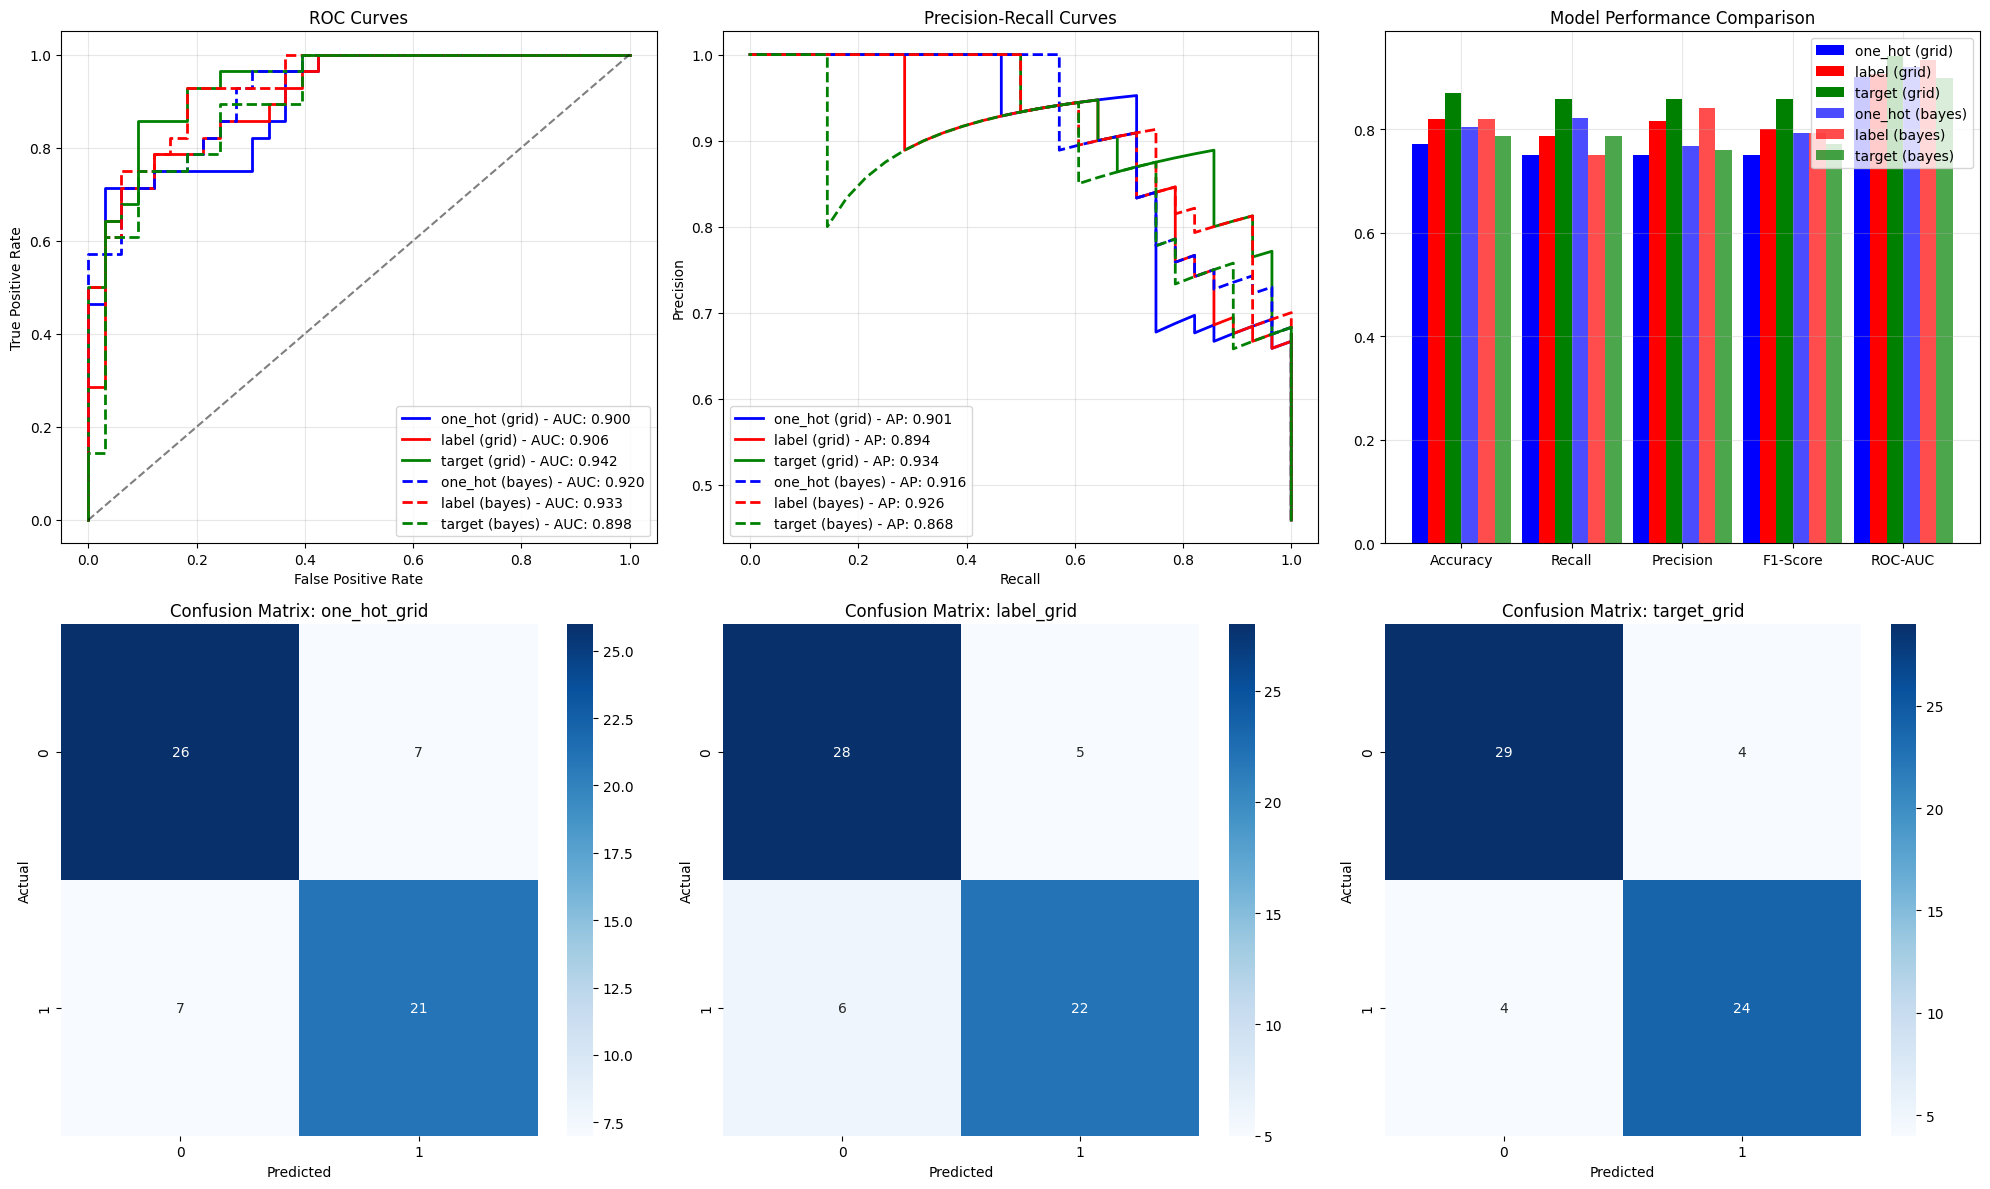

In [10]:
# --- CELL 10: Comprehensive Visualization ---
def plot_comprehensive_results(results, y_test, test_data_dict):
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    colors = {'one_hot': 'blue', 'label': 'red', 'target': 'green'}
    
    def get_encoding_type(k):
        if 'one_hot' in k: return 'one_hot'
        if 'label' in k: return 'label'
        if 'target' in k: return 'target'
        return 'unknown'

    # 1. ROC Curves
    ax = axes[0, 0]
    for key, result in results.items():
        encoding_type = get_encoding_type(key)
        optimization = key.split('_')[-1]
        if encoding_type not in colors: continue
        color = colors[encoding_type]
        linestyle = '-' if optimization == 'grid' else '--'
        fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
        ax.plot(fpr, tpr, color=color, linestyle=linestyle, linewidth=2, 
                label=f'{encoding_type} ({optimization}) - AUC: {result["roc_auc"]:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_title('ROC Curves')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Precision-Recall Curves
    ax = axes[0, 1]
    for key, result in results.items():
        encoding_type = get_encoding_type(key)
        optimization = key.split('_')[-1]
        if encoding_type not in colors: continue
        color = colors[encoding_type]
        linestyle = '-' if optimization == 'grid' else '--'
        precision, recall, _ = precision_recall_curve(y_test, result['y_pred_proba'])
        ax.plot(recall, precision, color=color, linestyle=linestyle, linewidth=2, 
                label=f'{encoding_type} ({optimization}) - AP: {result["avg_precision"]:.3f}')
    ax.set_title('Precision-Recall Curves')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Metrics Comparison
    ax = axes[0, 2]
    metrics = ['accuracy', 'recall', 'precision', 'f1', 'roc_auc']
    metric_names = ['Accuracy', 'Recall', 'Precision', 'F1-Score', 'ROC-AUC']
    x = np.arange(len(metrics))
    width = 0.15
    valid_keys = [k for k in results.keys() if get_encoding_type(k) in colors]
    for i, key in enumerate(valid_keys):
        encoding_type = get_encoding_type(key)
        optimization = key.split('_')[-1]
        color = colors[encoding_type]
        alpha = 1.0 if optimization == 'grid' else 0.7
        values = [results[key][metric] for metric in metrics]
        ax.bar(x + i*width, values, width, label=f'{encoding_type} ({optimization})', color=color, alpha=alpha)
    ax.set_title('Model Performance Comparison')
    ax.set_xticks(x + width*len(valid_keys)/2 - width/2)
    ax.set_xticklabels(metric_names)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Confusion Matrices
    for idx, key in enumerate(valid_keys[:3]): 
        ax = axes[1, idx]
        model = results[key]['model']
        encoding_type = get_encoding_type(key)
        if encoding_type in test_data_dict:
            X_input = test_data_dict[encoding_type]
            y_pred = model.predict(X_input)
            cm = confusion_matrix(y_test, y_pred)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
            ax.set_title(f'Confusion Matrix: {key}')
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual')
            
    plt.tight_layout()
    plt.show()

# Define test data dictionary
my_test_data = {
    'one_hot': X_test_oh,
    'label':   X_test_le,
    'target':  X_test_te
}

# Run plotting function
plot_comprehensive_results(results, y_test, my_test_data)

In [11]:
# --- CELL 11: Results Summary and Analysis ---
print("="*70)
print("FINAL GRADIENT BOOSTING ANALYSIS SUMMARY")
print("="*70)

# Create summary dataframe
summary_data = []
for key, result in results.items():
    enc_name = key.replace('_grid', '').replace('_bayes', '').replace('_', ' ')
    
    summary_data.append({
        'Encoding': enc_name,
        'Optimization': key.split('_')[-1],
        'Accuracy': f"{result['accuracy']:.4f}",
        'Recall': f"{result['recall']:.4f}",
        'Precision': f"{result['precision']:.4f}",
        'F1-Score': f"{result['f1']:.4f}",
        'ROC-AUC': f"{result['roc_auc']:.4f}",
        'Avg Precision': f"{result['avg_precision']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\nDetailed Performance Summary:")
print(summary_df.to_string(index=False))

# Find best model based on Recall
best_model_recall = max(results.items(), key=lambda x: x[1]['recall'])
best_model_f1 = max(results.items(), key=lambda x: x[1]['f1'])

print(f"\n⭐ BEST MODEL BY RECALL: {best_model_recall[0]}")
print(f"   Recall: {best_model_recall[1]['recall']:.4f}")
print(f"   F1-Score: {best_model_recall[1]['f1']:.4f}")

print(f"\n⭐ BEST MODEL BY F1-SCORE: {best_model_f1[0]}")
print(f"   F1-Score: {best_model_f1[1]['f1']:.4f}")
print(f"   Recall: {best_model_f1[1]['recall']:.4f}")

# Compare encoding methods
encoding_performance = {}
for encoding in ['one_hot', 'label', 'target']:
    encoding_results = [v for k, v in results.items() if k.startswith(encoding)]
    if encoding_results:
        avg_recall = np.mean([r['recall'] for r in encoding_results])
        encoding_performance[encoding] = avg_recall

best_encoding = max(encoding_performance.items(), key=lambda x: x[1])
print(f"\n📊 BEST ENCODING METHOD (Average Recall): {best_encoding[0]}")
print(f"   Average Recall: {best_encoding[1]:.4f}")

# Compare optimization methods
grid_results = [v for k, v in results.items() if k.endswith('grid')]
bayes_results = [v for k, v in results.items() if k.endswith('bayes')]

avg_grid_recall = np.mean([r['recall'] for r in grid_results])
avg_bayes_recall = np.mean([r['recall'] for r in bayes_results])

print(f"\n⚙️ OPTIMIZATION METHOD COMPARISON:")
print(f"   GridSearchCV Average Recall: {avg_grid_recall:.4f}")
print(f"   Bayesian Optimization Average Recall: {avg_bayes_recall:.4f}")

FINAL GRADIENT BOOSTING ANALYSIS SUMMARY

Detailed Performance Summary:
Encoding Optimization Accuracy Recall Precision F1-Score ROC-AUC Avg Precision
 one hot         grid   0.7705 0.7500    0.7500   0.7500  0.9004        0.9013
   label         grid   0.8197 0.7857    0.8148   0.8000  0.9058        0.8935
  target         grid   0.8689 0.8571    0.8571   0.8571  0.9416        0.9338
 one hot        bayes   0.8033 0.8214    0.7667   0.7931  0.9199        0.9158
   label        bayes   0.8197 0.7500    0.8400   0.7925  0.9329        0.9260
  target        bayes   0.7869 0.7857    0.7586   0.7719  0.8983        0.8683

⭐ BEST MODEL BY RECALL: target_grid
   Recall: 0.8571
   F1-Score: 0.8571

⭐ BEST MODEL BY F1-SCORE: target_grid
   F1-Score: 0.8571
   Recall: 0.8571

📊 BEST ENCODING METHOD (Average Recall): target
   Average Recall: 0.8214

⚙️ OPTIMIZATION METHOD COMPARISON:
   GridSearchCV Average Recall: 0.7976
   Bayesian Optimization Average Recall: 0.7857


In [12]:
# --- CORRECTED EXPORT CELL ---
import pickle

# 1. 👇 EDIT THESE TWO LINES FOR EACH NOTEBOOK:
MODEL_NAME = "Random Forest_Gradian Boost"        # Change this for each notebook (e.g. "SVM", "Random Forest")
BEST_KEY = 'target_grid'           # Change this to the best key you found in that notebook

# 2. Map the encoding names to your ACTUAL variables
# (These variable names match what is defined in Cells 5, 6, and 7)
test_sets = {
    'one_hot': X_test_oh,
    'label':   X_test_le,
    'target':  X_test_te
}

# 3. Determine the correct encoding type
if 'one_hot' in BEST_KEY:
    encoding = 'one_hot'
elif 'label' in BEST_KEY:
    encoding = 'label'
elif 'target' in BEST_KEY:
    encoding = 'target'
else:
    raise ValueError(f"Could not determine encoding from key: {BEST_KEY}")

# 4. Extract predictions using the correct dataset
best_result = results[BEST_KEY]
X_input = test_sets[encoding]  # Selects X_test_oh, X_test_le, or X_test_te

data_package = {
    'model_name': MODEL_NAME,
    'y_test': y_test,
    'y_pred': best_result['model'].predict(X_input),
    'y_proba': best_result['y_pred_proba']
}

# 5. Save to file
filename = f"{MODEL_NAME.lower().replace(' ', '_')}_data.pkl"
with open(filename, 'wb') as f:
    pickle.dump(data_package, f)

print(f"✅ Saved {MODEL_NAME} results to '{filename}'")

✅ Saved Random Forest_Gradian Boost results to 'random_forest_gradian_boost_data.pkl'
